Llama 3.2 From Scratch (A Standalone Notebook)
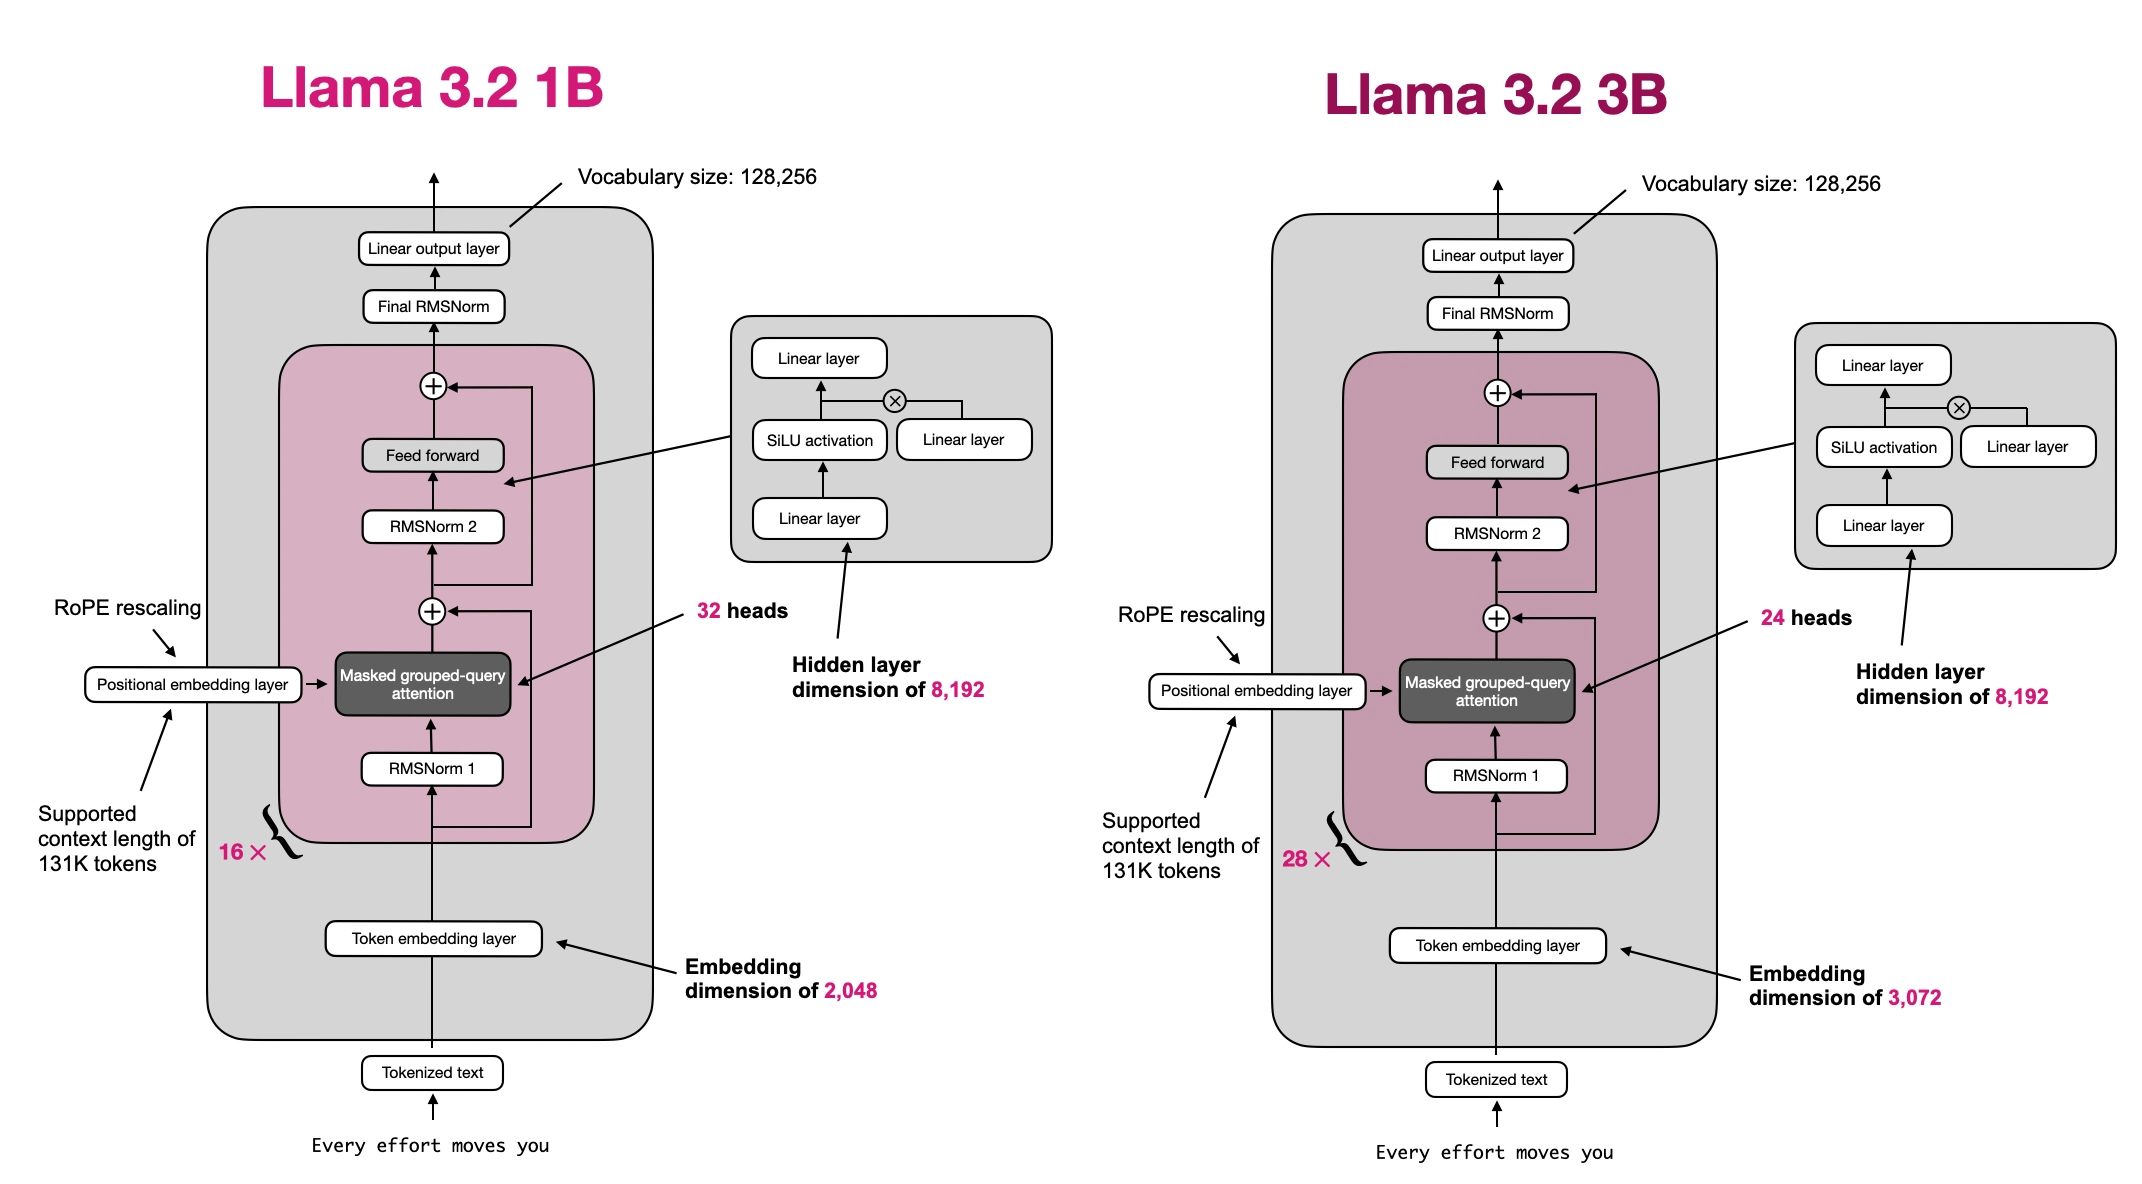

In [ ]:
# 中文注释：用于查询已安装第三方库版本号的标准库函数
from importlib.metadata import version

# 中文注释：列出本notebook依赖的关键第三方库，并逐一打印当前安装的版本，便于排查环境/依赖问题
pkgs = [
    "blobfile",         # to download pretrained weights
    "huggingface_hub",  # to download pretrained weights
    "tiktoken",         # to implement the tokenizer
    "torch",            # to implement the model
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

1. Architecture code

In [ ]:
# 中文注释：PyTorch 核心库，用于构建张量运算和神经网络模块
import torch
import torch.nn as nn


# 中文注释：SwiGLU 前馈网络（Llama 系列使用的 FFN 结构），相比 GPT 的 GELU-MLP，使用门控线性单元：fc1(门控分支) 经 SiLU 激活后与 fc2(数值分支) 逐元素相乘，再经 fc3 投影回原始维度；三个线性层均不使用 bias，直接以低精度 dtype（如 bfloat16）创建权重
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 中文注释：fc1 将 emb_dim -> hidden_dim，用作 SwiGLU 的"门控(gate)"分支，加载权重时对应 gate_proj
        self.fc1 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        # 中文注释：fc2 同样 emb_dim -> hidden_dim，用作"数值(up)"分支，加载权重时对应 up_proj
        self.fc2 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        # 中文注释：fc3 将 hidden_dim -> emb_dim 投影回原始维度，加载权重时对应 down_proj
        self.fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], dtype=cfg["dtype"], bias=False)

    def forward(self, x):
        # 中文注释：x 形状为 (batch_size, num_tokens, emb_dim)
        # 中文注释：x_fc1 形状 (batch_size, num_tokens, hidden_dim)，作为门控分支
        x_fc1 = self.fc1(x)
        # 中文注释：x_fc2 形状同上，作为数值分支
        x_fc2 = self.fc2(x)
        # 中文注释：SiLU(x_fc1) 生成门控信号，与 x_fc2 逐元素相乘 —— 这就是 SwiGLU 的核心计算
        x = nn.functional.silu(x_fc1) * x_fc2
        # 中文注释：最终投影回 (batch_size, num_tokens, emb_dim)
        return self.fc3(x)
# 中文注释：RoPE（旋转位置编码）参数预计算函数。核心思想：为每一对特征维度分配一个固定频率，通过旋转角度 = 位置 x 频率 来注入位置信息，使得 Q、K 的点积天然携带相对位置信息，无需额外的可学习位置向量。
# 中文注释：Llama 3.1/3.2 在原始 RoPE 基础上增加了"频率缩放"(freq_config)，用于将预训练时的短上下文（如 8192）外推到更长的上下文（如 131072）而不重新训练。
def compute_rope_params(head_dim, theta_base=10_000, context_length=4096, freq_config=None, dtype=torch.float32):
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    # 中文注释：inv_freq 形状 (head_dim // 2,)，第 i 个分量为 theta_base^(-2i/head_dim)，频率随维度增大而指数衰减（低维快速旋转，高维缓慢旋转）
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, dtype=dtype)[: (head_dim // 2)].float() / head_dim))

    # Frequency adjustments
    # 中文注释：以下为 Llama 3.x 的 RoPE 频率缩放（NTK/YaRN 风格的分段缩放），根据每个频率对应的"波长"相对原始训练上下文长度的大小，分三段处理：
    # 中文注释：1) 波长很长（低频，wavelen > low_freq_wavelen）：按 factor 整体降频，拉长有效周期以适应更长上下文
    # 中文注释：2) 波长很短（高频，wavelen < high_freq_wavelen）：保持原始频率不变，短距离位置关系不受影响
    # 中文注释：3) 中间频段：在两者之间做线性插值平滑过渡，避免频率突变
    if freq_config is not None:
        low_freq_wavelen = freq_config["original_context_length"] / freq_config["low_freq_factor"]
        high_freq_wavelen = freq_config["original_context_length"] / freq_config["high_freq_factor"]

        # 中文注释：将频率换算为波长，形状 (head_dim // 2,)
        wavelen = 2 * torch.pi / inv_freq

        # 中文注释：低频部分（长波长）按 factor 缩小频率
        inv_freq_llama = torch.where(
            wavelen > low_freq_wavelen, inv_freq / freq_config["factor"], inv_freq
        )

        # 中文注释：计算中间频段的线性插值系数 smooth_factor
        smooth_factor = (freq_config["original_context_length"] / wavelen - freq_config["low_freq_factor"]) / (
            freq_config["high_freq_factor"] - freq_config["low_freq_factor"]
        )

        # 中文注释：在"缩放后的频率"与"原始频率"之间做平滑插值
        smoothed_inv_freq = (
            (1 - smooth_factor) * (inv_freq / freq_config["factor"]) + smooth_factor * inv_freq
        )

        # 中文注释：仅在中间频段（波长介于 high/low 之间）使用平滑插值结果，其余维持之前的分段结果
        is_medium_freq = (wavelen <= low_freq_wavelen) & (wavelen >= high_freq_wavelen)
        inv_freq_llama = torch.where(is_medium_freq, smoothed_inv_freq, inv_freq_llama)
        inv_freq = inv_freq_llama

    # Generate position indices
    # 中文注释：positions 形状 (context_length,)，即 0, 1, 2, ..., context_length-1
    positions = torch.arange(context_length, dtype=dtype)

    # Compute the angles
    # 中文注释：外积得到每个位置、每个频率对应的旋转角度，形状 (context_length, head_dim // 2)
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    # 中文注释：将角度矩阵复制拼接一份，使最后一维扩展到 head_dim，对应"旋转一半(rotate half)"实现方式：前半和后半使用相同角度
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    # 中文注释：预先算好所有位置的 cos/sin 表，形状均为 (context_length, head_dim)，后续直接查表使用，避免重复计算三角函数
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin


# 中文注释：将预计算好的 RoPE 旋转编码实际应用到 Q 或 K 张量上
def apply_rope(x, cos, sin):
    # x: (batch_size, num_heads, seq_len, head_dim)
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    # Split x into first half and second half
    # 中文注释："旋转一半"(rotate_half) 技巧：把最后一维切成前后两半，形状均为 (batch_size, num_heads, seq_len, head_dim//2)
    x1 = x[..., : head_dim // 2]  # First half
    x2 = x[..., head_dim // 2 :]  # Second half

    # Adjust sin and cos shapes
    # 中文注释：从预计算表中按当前序列长度截取，并扩展出 batch、head 两个维度以便广播相乘
    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)

    # Apply the rotary transformation
    # 中文注释：拼接 [-x2, x1] 得到"旋转后"的向量；x*cos + rotate_half(x)*sin 等价于对每对二维子向量做旋转矩阵变换，这是 RoPE 复数旋转公式 e^{i*theta} 的实数（矩阵）实现
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    # It's ok to use lower-precision after applying cos and sin rotation
    # 中文注释：cos/sin 用 float32 精度计算保证数值稳定，旋转完成后再转换回原始（更低精度的）dtype
    return x_rotated.to(dtype=x.dtype)
# 中文注释：分组查询注意力（Grouped-Query Attention, GQA）。与标准多头注意力（MHA）不同：Q 仍然保留 num_heads 个独立头，但 K、V 只投影出 num_kv_groups（更少）组，多个 Q 头共享同一组 K/V，从而大幅减少 K/V 参数量与推理时 KV Cache 显存占用，是 Llama 2/3 系列的关键设计之一。
class GroupedQueryAttention(nn.Module):
    def __init__(
            self, d_in, d_out, num_heads,
            num_kv_groups,
            dtype=None
        ):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"

        self.d_out = d_out
        self.num_heads = num_heads
        # 中文注释：每个注意力头的维度 = 总维度 / 头数
        self.head_dim = d_out // num_heads

        # 中文注释：K、V 的输出维度是 num_kv_groups * head_dim，而非 num_heads * head_dim，这正是 GQA 相比标准 MHA 节省参数之处（例如 Llama3.2-1B: num_heads=32, num_kv_groups=8）
        self.W_key = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.num_kv_groups = num_kv_groups
        # 中文注释：group_size 表示每一组 K/V 被多少个 Q 头共享
        self.group_size = num_heads // num_kv_groups

        # 中文注释：Q 仍投影到完整 d_out = num_heads * head_dim
        self.W_query = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(d_out, d_out, bias=False, dtype=dtype)

    def forward(self, x, mask, cos, sin):
        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)  # Shape: (b, num_tokens, d_out)
        keys = self.W_key(x)  # Shape: (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x)  # Shape: (b, num_tokens, num_kv_groups * head_dim)

        # Reshape queries, keys, and values
        # 中文注释：拆出多头维度；注意 keys/values 拆出的是 num_kv_groups（比 num_heads 少）
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim)
        values = values.view(b, num_tokens, self.num_kv_groups, self.head_dim)

        # Transpose keys, values, and queries
        keys = keys.transpose(1, 2)  # Shape: (b, num_kv_groups, num_tokens, head_dim)
        values = values.transpose(1, 2)  # Shape: (b, num_kv_groups, num_tokens, head_dim)
        queries = queries.transpose(1, 2)  # Shape: (b, num_heads, num_tokens, head_dim)

        # Apply RoPE
        # 中文注释：对 Q、K 分别施加旋转位置编码（V 不参与，因为 RoPE 只影响 Q·K 的注意力打分）
        keys = apply_rope(keys, cos, sin)
        queries = apply_rope(queries, cos, sin)

        # Expand keys and values to match the number of heads
        # Shape: (b, num_heads, num_tokens, head_dim)
        # 中文注释：用 repeat_interleave 把每组 K/V 复制 group_size 份，使其数量与 Q 头数对齐，之后就能像普通多头注意力一样逐头做矩阵乘法（GQA 的"共享"体现在复制的是同一份底层数据）
        keys = keys.repeat_interleave(self.group_size, dim=1)  # Shape: (b, num_heads, num_tokens, head_dim)
        values = values.repeat_interleave(self.group_size, dim=1)  # Shape: (b, num_heads, num_tokens, head_dim)
        # For example, before repeat_interleave along dim=1 (query groups):
        #   [K1, K2]
        # After repeat_interleave (each query group is repeated group_size times):
        #   [K1, K1, K2, K2]
        # If we used regular repeat instead of repeat_interleave, we'd get:
        #   [K1, K2, K1, K2]

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        # Shape: (b, num_heads, num_tokens, num_tokens)
        # 中文注释：Q·K^T 得到每个头的原始注意力分数
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Compute attention scores
        # 中文注释：mask 为上三角布尔矩阵（不含主对角线），True 处代表"未来位置"，填充 -inf 实现因果自回归掩码
        attn_scores = attn_scores.masked_fill(mask, -torch.inf)

        # 中文注释：按 sqrt(head_dim) 缩放后做 softmax 得到注意力权重
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        assert keys.shape[-1] == self.head_dim

        # Shape: (b, num_tokens, num_heads, head_dim)
        # 中文注释：注意力权重与 V 加权求和，得到每个头的上下文向量
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        # 中文注释：把多头拼接回单一向量，再经输出投影融合各头信息
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec
# 中文注释：Transformer 解码器块，采用 Pre-Norm 结构（先归一化再进子层再残差相加），归一化方式为 RMSNorm（均方根归一化，比 LayerNorm 少了减均值步骤，计算更省，是 Llama 系列标配）
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = GroupedQueryAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            num_kv_groups=cfg["n_kv_groups"],
            dtype=cfg["dtype"]
        )
        self.ff = FeedForward(cfg)
        # 中文注释：norm1 用在注意力子层之前，norm2 用在前馈子层之前，均使用 PyTorch 内置 nn.RMSNorm
        self.norm1 = nn.RMSNorm(cfg["emb_dim"], eps=1e-5, dtype=cfg["dtype"])
        self.norm2 = nn.RMSNorm(cfg["emb_dim"], eps=1e-5, dtype=cfg["dtype"])

    def forward(self, x, mask, cos, sin):
        # Shortcut connection for attention block
        # 中文注释：Pre-Norm + 残差：x -> RMSNorm -> 注意力 -> 与归一化前的 x（shortcut）相加
        shortcut = x
        x = self.norm1(x)
        x = self.att(x, mask, cos, sin)  # Shape [batch_size, num_tokens, emb_size]
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        # 中文注释：同样的 Pre-Norm + 残差模式应用于 SwiGLU 前馈子层
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = x + shortcut  # Add the original input back

        return x
# 中文注释：完整的 Llama 3 模型：词嵌入 -> N 层 TransformerBlock -> 最终 RMSNorm -> 输出投影头（生成 logits）
class Llama3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Main model parameters
        # 中文注释：词嵌入层，把 token id 映射为 emb_dim 维向量；注意 Llama 不使用可学习的绝对位置嵌入，位置信息全部来自 RoPE
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])

        self.trf_blocks = nn.ModuleList(  # ModuleList since Sequential can only accept one input, and we need `x, mask, cos, sin`
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = nn.RMSNorm(cfg["emb_dim"], eps=1e-5, dtype=cfg["dtype"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])

        # Reusable utilities
        # 中文注释：初始化时一次性预计算好 RoPE 的 cos/sin 表（覆盖整个 context_length），所有层共享，避免重复计算
        cos, sin = compute_rope_params(
            head_dim=cfg["emb_dim"] // cfg["n_heads"],
            theta_base=cfg["rope_base"],
            context_length=cfg["context_length"],
            freq_config=cfg["rope_freq"]
        )
        # 中文注释：persistent=False 表示 cos/sin 不会被保存进 state_dict（可随时重新计算，节省权重文件体积）
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        self.cfg = cfg


    def forward(self, in_idx):
        # Forward pass
        # 中文注释：in_idx 形状 (batch_size, num_tokens)，为 token id 序列
        tok_embeds = self.tok_emb(in_idx)
        x = tok_embeds

        num_tokens = x.shape[1]
        # 中文注释：动态构造因果掩码（上三角为 True，不含主对角线），形状 (num_tokens, num_tokens)，每次前向按当前序列长度重新生成
        mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1)

        # 中文注释：依次通过每一层 TransformerBlock，共享同一份预计算的 cos/sin 与掩码
        for block in self.trf_blocks:
            x = block(x, mask, self.cos, self.sin)
        x = self.final_norm(x)
        # 中文注释：投影到词表大小得到 logits，形状 (batch_size, num_tokens, vocab_size)；先把 x 转换回目标 dtype 再做最后的线性层，控制精度与显存开销
        logits = self.out_head(x.to(self.cfg["dtype"]))
        return logits

2. Initialize model

In [ ]:
# Llama 3.2 1B
# 中文注释：Llama 3.2 1B 模型超参数配置说明：vocab_size 词表大小；context_length 预训练/支持的最大上下文长度；emb_dim 嵌入/隐藏维度；n_heads Q 的注意力头数；n_layers Transformer 层数
# 中文注释：hidden_dim SwiGLU 前馈网络中间层维度；n_kv_groups GQA 的 K/V 组数（32 个 Q 头共享 8 组 K/V，每组被 4 个头共享）
# 中文注释：rope_base RoPE 旋转公式中的 theta 底数；dtype 模型权重使用的低精度类型（bfloat16 节省显存）；rope_freq Llama3 特有的 RoPE 分段频率缩放参数，用于将预训练的 8192 上下文外推到 131072

LLAMA32_CONFIG = {
    "vocab_size": 128_256,           # Vocabulary size
    "context_length": 131_072,       # Context length that was used to train the model
    "emb_dim": 2048,                 # Embedding dimension
    "n_heads": 32,                   # Number of attention heads
    "n_layers": 16,                  # Number of layers
    "hidden_dim": 8192,              # Size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,                # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,          # The base in RoPE's "theta"
    "dtype": torch.bfloat16,         # Lower-precision dtype to reduce memory usage
    "rope_freq": {                   # RoPE frequency scaling
        "factor": 32.0,
        "low_freq_factor": 1.0,
        "high_freq_factor": 4.0,
        "original_context_length": 8192,
    }
}

# Llama 3.2 3B
# 中文注释：以下为 3B 版本的备用配置（保持注释状态未启用），字段含义与上方 1B 配置相同

# LLAMA32_CONFIG = {
#     "vocab_size": 128_256,           # Vocabulary size
#     "context_length": 131_072,       # Context length that was used to train the model
#     "emb_dim": 3072,                 # Embedding dimension
#     "n_heads": 24,                   # Number of attention heads
#     "n_layers": 28,                  # Number of layers
#     "hidden_dim": 8192,              # Size of the intermediate dimension in FeedForward
#     "n_kv_groups": 8,                # Key-Value groups for grouped-query attention
#     "rope_base": 500_000.0,          # The base in RoPE's "theta"
#     "dtype": torch.bfloat16,         # Lower-precision dtype to reduce memory usage
#     "rope_freq": {                   # RoPE frequency scaling
#         "factor": 32.0,
#         "low_freq_factor": 1.0,
#         "high_freq_factor": 4.0,
#         "original_context_length": 8192,
#     }
# }

# 中文注释：根据 emb_dim 是否等于 2048 判断当前是 1B 还是 3B，用于拼接 HuggingFace 仓库名（如 meta-llama/Llama-3.2-1B-Instruct）
LLAMA_SIZE_STR = "1B" if LLAMA32_CONFIG["emb_dim"] == 2048 else "3B"
# 中文注释：实例化模型结构；此时所有权重均为随机初始化，真正的预训练权重会在第4节从 HuggingFace 下载后加载进来
model = Llama3Model(LLAMA32_CONFIG)
# 中文注释：估算模型在指定 dtype 下所需显存（参数 + 梯度 + 缓冲区），用于直观对比 float32 与 bfloat16 的显存差异
def calc_model_memory_size(model, input_dtype=torch.float32):
    total_params = 0
    total_grads = 0
    for param in model.parameters():
        # Calculate total number of elements per parameter
        param_size = param.numel()
        total_params += param_size
        # Check if gradients are stored for this parameter
        if param.requires_grad:
            total_grads += param_size

    # Calculate buffer size (non-parameters that require memory)
    total_buffers = sum(buf.numel() for buf in model.buffers())

    # Size in bytes = (Number of elements) * (Size of each element in bytes)
    # We assume parameters and gradients are stored in the same type as input dtype
    element_size = torch.tensor(0, dtype=input_dtype).element_size()
    total_memory_bytes = (total_params + total_grads + total_buffers) * element_size

    # Convert bytes to gigabytes
    total_memory_gb = total_memory_bytes / (1024**3)

    return total_memory_gb

print(f"float32 (PyTorch default): {calc_model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16: {calc_model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

In [ ]:
# 中文注释：统计模型中所有参数（含权重共享/绑定重复计入）的元素总数
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

# Account for weight tying
# 中文注释：若词嵌入层与输出头共享同一份权重（weight tying），numel() 会把它重复计入两次，这里减去一次 tok_emb 的参数量，得到"去重后"的真实参数总数
total_params_normalized = total_params - model.tok_emb.weight.numel()
print(f"\nTotal number of unique parameters: {total_params_normalized:,}")

In [ ]:
# 中文注释：按优先级自动选择计算设备：NVIDIA GPU (cuda) > Apple Silicon GPU (mps) > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# 中文注释：把模型的全部参数和缓冲区搬到选定设备上；末尾分号用于抑制 Jupyter 自动打印返回值
model.to(device);

3. Load tokenizer

In [ ]:
# 中文注释：标准库，用于检查文件是否存在
import os
# 中文注释：面向对象的路径处理工具
from pathlib import Path

# 中文注释：OpenAI 开源的高性能 BPE 分词库，Llama 3 的分词器基于 tiktoken 的 BPE 规则实现
import tiktoken
# 中文注释：用于从 .model 文件中加载 tiktoken 格式的可合并 BPE 词表（mergeable ranks）
from tiktoken.load import load_tiktoken_bpe



# 中文注释：对 tiktoken 的一层薄封装，额外维护 Llama 3 的特殊 token（如对话起止符）
class Tokenizer:
    """Thin wrapper around tiktoken that keeps track of Llama-3 special IDs."""
    def __init__(self, model_path):
        if not os.path.isfile(model_path):
            raise FileNotFoundError(model_path)

        # 中文注释：加载官方 tokenizer.model 中的 BPE 合并规则表
        mergeable = load_tiktoken_bpe(model_path)

        # hard-coded from Meta's tokenizer.json
        # 中文注释：Llama 3 特殊 token 的固定 id，来自 Meta 官方 tokenizer.json 配置
        self.special = {
            "<|begin_of_text|>": 128000,
            "<|end_of_text|>": 128001,
            "<|start_header_id|>": 128006,
            "<|end_header_id|>": 128007,
            "<|eot_id|>": 128009,
        }
        # 中文注释：补充剩余的"保留位" token id（跳过已经在上面用到的 id），凑满特殊 token 的 id 区间
        self.special.update({f"<|reserved_{i}|>": 128002 + i
                             for i in range(256)
                             if 128002 + i not in self.special.values()})

        # 中文注释：用官方的正则切分规则 + BPE 合并表 + 特殊 token，构造 tiktoken 编码器
        self.model = tiktoken.Encoding(
            name=Path(model_path).name,
            pat_str=r"(?i:'s|'t|'re|'ve|'m|'ll|'d)"
                    r"|[^\r\n\p{L}\p{N}]?\p{L}+"
                    r"|\p{N}{1,3}"
                    r"| ?[^\s\p{L}\p{N}]+[\r\n]*"
                    r"|\s*[\r\n]+"
                    r"|\s+(?!\S)"
                    r"|\s+",
            mergeable_ranks=mergeable,
            special_tokens=self.special,
        )

    def encode(self, text, bos=False, eos=False):
        # 中文注释：可选地在序列开头加 <|begin_of_text|>，结尾加 <|end_of_text|>
        ids = ([self.special["<|begin_of_text|>"]] if bos else []) \
              + self.model.encode(text)
        if eos:
            ids.append(self.special["<|end_of_text|>"])
        return ids

    def decode(self, ids):
        return self.model.decode(ids)


# 中文注释：把 system/user/assistant 多轮对话拼接成 Llama 3 指令模型所需的 prompt token 序列（对话模板）
class ChatFormat:

    def __init__(self, tokenizer: Tokenizer, *,
                 default_system="You are a helpful assistant."):
        self.tok = tokenizer
        self.default_system = default_system

    def _header(self, role):
        """Encode <|start_header_id|>role<|end_header_id|>\n\n"""
        # 中文注释：编码形如 <|start_header_id|>system<|end_header_id|>\n\n 的角色头部
        return (
            [self.tok.special["<|start_header_id|>"]]
            + self.tok.encode(role)
            + [self.tok.special["<|end_header_id|>"]]
            + self.tok.encode("\n\n")
        )

    def encode(self, user_message, system_message=None):
        sys_msg = system_message if system_message is not None else self.default_system

        # 中文注释：整段 prompt 以 <|begin_of_text|> 开头
        ids = [self.tok.special["<|begin_of_text|>"]]

        # system
        # 中文注释：拼接 system 角色头 + system 消息内容 + 消息结束符 <|eot_id|>
        ids += self._header("system")
        ids += self.tok.encode(sys_msg)
        ids += [self.tok.special["<|eot_id|>"]]

        # user
        # 中文注释：拼接 user 角色头 + 用户输入内容 + 结束符
        ids += self._header("user")
        ids += self.tok.encode(user_message)
        ids += [self.tok.special["<|eot_id|>"]]

        # assistant header (no content yet)
        # 中文注释：最后只拼接 assistant 角色头（不含内容），留给模型自回归生成后续回复
        ids += self._header("assistant")

        return ids

In [ ]:
# 中文注释：HuggingFace Hub 客户端，用于从远程仓库下载模型/分词器文件（首次运行需联网，部分模型需先在HF上申请访问权限）
from huggingface_hub import hf_hub_download

# 中文注释：下载 Meta 官方 tokenizer.model 文件到本地目录，repo_id 根据前面判断出的 1B/3B 自动拼接
tokenizer_file_path = hf_hub_download(
    repo_id=f"meta-llama/Llama-3.2-{LLAMA_SIZE_STR}-Instruct",
    filename="original/tokenizer.model",
    local_dir=f"Llama-3.2-{LLAMA_SIZE_STR}-Instruct"
)

In [ ]:
# 中文注释：加载底层 BPE 分词器
tokenizer = Tokenizer(tokenizer_file_path)
# 中文注释：在其基础上包一层对话模板封装，供后续生成时构造带 system/user 角色的 prompt
chat_tokenizer = ChatFormat(tokenizer)

4. Load pretrained weights

In [ ]:
# 中文注释：将 HuggingFace safetensors 中读取出的权重张量 right，安全地拷贝赋值给模型自身的参数 left，先校验形状是否一致，避免因权重名/形状写错而静默出错
def assign(left, right, tensor_name="unknown"):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch in tensor '{tensor_name}'. Left: {left.shape}, Right: {right.shape}")

    with torch.no_grad():
        if isinstance(right, torch.Tensor):
            left.copy_(right)
        else:
            left.copy_(torch.as_tensor(right, dtype=left.dtype, device=left.device))

    return left


# 中文注释：把 HuggingFace 格式（Llama 官方 state_dict 命名）的权重逐一映射并加载进本notebook自定义的 Llama3Model 结构中
def load_weights_into_llama(model, param_config, params):
    # 中文注释：词嵌入权重
    model.tok_emb.weight = assign(model.tok_emb.weight, params["model.embed_tokens.weight"], "model.embed_tokens.weight")

    for l in range(param_config["n_layers"]):

        # Load attention weights
        # 中文注释：q_proj / k_proj / v_proj / o_proj 分别对应本模型的 W_query / W_key / W_value / out_proj；注意 k_proj、v_proj 的输出维度是 num_kv_groups * head_dim（GQA 结构），形状会比 q_proj 小
        model.trf_blocks[l].att.W_query.weight = assign(
            model.trf_blocks[l].att.W_query.weight,
            params[f"model.layers.{l}.self_attn.q_proj.weight"],
            f"model.layers.{l}.self_attn.q_proj.weight"
        )
        model.trf_blocks[l].att.W_key.weight = assign(
            model.trf_blocks[l].att.W_key.weight,
            params[f"model.layers.{l}.self_attn.k_proj.weight"],
            f"model.layers.{l}.self_attn.k_proj.weight"
        )
        model.trf_blocks[l].att.W_value.weight = assign(
            model.trf_blocks[l].att.W_value.weight,
            params[f"model.layers.{l}.self_attn.v_proj.weight"],
            f"model.layers.{l}.self_attn.v_proj.weight"
        )
        model.trf_blocks[l].att.out_proj.weight = assign(
            model.trf_blocks[l].att.out_proj.weight,
            params[f"model.layers.{l}.self_attn.o_proj.weight"],
            f"model.layers.{l}.self_attn.o_proj.weight"
        )
        # 中文注释：input_layernorm 对应 attention 前的 norm1（RMSNorm 权重）
        model.trf_blocks[l].norm1.weight = assign(
            model.trf_blocks[l].norm1.weight,
            params[f"model.layers.{l}.input_layernorm.weight"],
            f"model.layers.{l}.input_layernorm.weight"
        )

        # Load FeedForward weights
        # 中文注释：gate_proj / up_proj / down_proj 分别对应本模型 SwiGLU 的 fc1(门控) / fc2(数值) / fc3(下投影)
        model.trf_blocks[l].ff.fc1.weight = assign(
            model.trf_blocks[l].ff.fc1.weight,
            params[f"model.layers.{l}.mlp.gate_proj.weight"],
            f"model.layers.{l}.mlp.gate_proj.weight"
        )
        model.trf_blocks[l].ff.fc2.weight = assign(
            model.trf_blocks[l].ff.fc2.weight,
            params[f"model.layers.{l}.mlp.up_proj.weight"],
            f"model.layers.{l}.mlp.up_proj.weight"
        )
        model.trf_blocks[l].ff.fc3.weight = assign(
            model.trf_blocks[l].ff.fc3.weight,
            params[f"model.layers.{l}.mlp.down_proj.weight"],
            f"model.layers.{l}.mlp.down_proj.weight"
        )
        # 中文注释：post_attention_layernorm 对应前馈子层前的 norm2
        model.trf_blocks[l].norm2.weight = assign(
            model.trf_blocks[l].norm2.weight,
            params[f"model.layers.{l}.post_attention_layernorm.weight"],
            f"model.layers.{l}.post_attention_layernorm.weight"
        )

    # Load output layer weights
    # 中文注释：最终的 RMSNorm 权重
    model.final_norm.weight = assign(model.final_norm.weight, params["model.norm.weight"], "model.norm.weight")

    # 中文注释：若权重文件中单独存有 lm_head.weight，则直接加载；否则说明该模型采用"权重绑定"（weight tying），输出头与词嵌入共享同一份权重（1B/3B 模型均如此）
    if "lm_head.weight" in params.keys():
        model.out_head.weight = assign(model.out_head.weight, params["lm_head.weight"], "lm_head.weight")
    else:
        model.out_head.weight = model.tok_emb.weight
        print("Model uses weight tying.")

In [ ]:
# 中文注释：用于读取 HuggingFace safetensors 格式的权重文件（比 pickle 的 .bin 更安全、加载更快）
from safetensors.torch import load_file


# 中文注释：1B 模型权重只有一个 safetensors 文件，直接下载加载
if LLAMA_SIZE_STR == "1B":
    weights_file = hf_hub_download(
        repo_id=f"meta-llama/Llama-3.2-{LLAMA_SIZE_STR}-Instruct",
        filename="model.safetensors",
        local_dir=f"Llama-3.2-{LLAMA_SIZE_STR}-Instruct"
    )
    combined_weights = load_file(weights_file)


# 中文注释：3B 模型权重被切分成两个分片文件，需要分别下载后合并到同一个字典中
else:
    combined_weights = {}
    for i in range(1, 3):
        weights_file = hf_hub_download(
            repo_id=f"meta-llama/Llama-3.2-{LLAMA_SIZE_STR}-Instruct",
            filename=f"model-0000{i}-of-00002.safetensors",
            local_dir=f"Llama-3.2-{LLAMA_SIZE_STR}-Instruct"
        )
        current_weights = load_file(weights_file)
        combined_weights.update(current_weights)


# 中文注释：把下载好的官方权重按名称映射加载进模型，再搬到目标计算设备
load_weights_into_llama(model, LLAMA32_CONFIG, combined_weights)
model.to(device)
del combined_weights  # free up memory
# 中文注释：统计模型中"物理上不重复"的参数量——通过 data_ptr() 判断是否共享同一块内存，权重绑定（tok_emb 与 out_head 共享）的部分只会被计入一次，比 cell 6 中简单相减的方式更通用、更严谨
def count_unique_parameters(model):
    unique_params = set()
    total_unique_params = 0

    for param in model.parameters():
        if param.data_ptr() not in unique_params:
            total_unique_params += param.numel()
            unique_params.add(param.data_ptr())

    return total_unique_params

total_params_uniq = count_unique_parameters(model)
print(f"Total number of unique parameters: {total_params_uniq:,}")

In [ ]:
# Checks that the weight values are the same
# 中文注释：比较两个权重张量的数值是否完全相等，验证权重绑定是否生效（数值层面）
print("Weight tying:", torch.equal(model.tok_emb.weight, model.out_head.weight))

In [ ]:
# Furthermore, check if PyTorch uses the same underlying memory
# 中文注释：进一步比较底层内存地址(data_ptr)是否相同，确认二者确实是同一份张量对象而非"数值恰好相等的两份拷贝"
print("Weight tying:", model.tok_emb.weight.data_ptr() == model.out_head.weight.data_ptr())

5. Generate text

In [ ]:
# 中文注释：把文本编码为 token id 张量，并添加 batch 维度，形状变为 (1, num_tokens)
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor


# 中文注释：把模型输出的 token id 张量解码回文本；先去掉 batch 维度再转成 list 交给分词器解码
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())


# 中文注释：自回归文本生成主循环。每一步用当前已生成的全部 token 做一次前向计算，只取最后一个位置的 logits 来预测下一个 token，再把新 token 拼接回序列，循环 max_new_tokens 次。
# 中文注释：注意：这里没有实现 KV Cache，因此每步都会对完整（截断后的）上下文重新计算，属于教学简化版实现
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        # 中文注释：只保留最近 context_size 个 token，防止超出模型支持的最大上下文长度
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            # 中文注释：形状 (batch_size, num_tokens, vocab_size)
            logits = model(idx_cond)
        # 中文注释：只取最后一个时间步的 logits，形状 (batch_size, vocab_size)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        # 中文注释：Top-k 采样：只保留概率最高的 k 个候选 token，其余全部置为 -inf（禁止被采样到）
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)

        # New: Apply temperature scaling
        # 中文注释：温度采样：temperature 越大分布越平滑（更随机），越小越接近贪心
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            # 中文注释：按概率分布随机采样一个 token（而非总是取最大值），增加生成多样性
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        # 中文注释：temperature<=0 时退化为贪心解码：直接取概率最高的 token（本notebook示例中 top_k=1, temperature=0，等价于贪心）
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        # 中文注释：遇到结束符提前停止；注意此写法用 == 比较张量假设 batch_size=1，若批量生成需逐样本判断（风险点，未修改原逻辑）
        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        # 中文注释：把新生成的 token 拼接到序列末尾，作为下一轮迭代的输入
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [ ]:
# 中文注释：用于计时，衡量生成过程耗时
import time


# 中文注释：待生成的用户输入文本
PROMPT = "What do llamas eat?"

# 中文注释：固定随机种子，保证多次运行结果可复现（本例 temperature=0 走贪心路径，理论上不依赖随机数）
torch.manual_seed(123)

start = time.time()

# 中文注释：注意这里传入的是 chat_tokenizer（ChatFormat 实例）而非普通 tokenizer，text_to_token_ids 内部调用 tokenizer.encode(text) 时，实际调用的是 ChatFormat.encode，会自动套上 system/user/assistant 的对话模板头，而不是对 PROMPT 做裸编码
token_ids = generate(
    model=model,
    idx=text_to_token_ids(PROMPT, chat_tokenizer).to(device),
    max_new_tokens=150,
    context_size=LLAMA32_CONFIG["context_length"],
    top_k=1,
    temperature=0.
)

print(f"Time: {time.time() - start:.2f} sec")

# 中文注释：若在 GPU 上运行，额外打印本次推理峰值显存占用，便于评估资源需求
if torch.cuda.is_available():
    max_mem_bytes = torch.cuda.max_memory_allocated()
    max_mem_gb = max_mem_bytes / (1024 ** 3)
    print(f"Max memory allocated: {max_mem_gb:.2f} GB")

# 中文注释：用普通 tokenizer（非 ChatFormat）把完整的输出 token 序列解码回文本，此时文本中会包含对话模板的特殊标记（如 <|start_header_id|>assistant<|end_header_id|> 等）
output_text = token_ids_to_text(token_ids, tokenizer)


# 中文注释：从解码后的完整文本中截取"assistant 头部之后"的部分，去掉前面的 system/user 模板内容，只保留模型真正生成的回复
def clean_text(text, header_end="assistant<|end_header_id|>\n\n"):
    # Find the index of the first occurrence of "<|end_header_id|>"
    index = text.find(header_end)

    if index != -1:
        # Return the substring starting after "<|end_header_id|>"
        return text[index + len(header_end):].strip()  # Strip removes leading/trailing whitespace
    else:
        # If the token is not found, return the original text
        return text

print("\n\nOutput text:\n\n", clean_text(output_text))

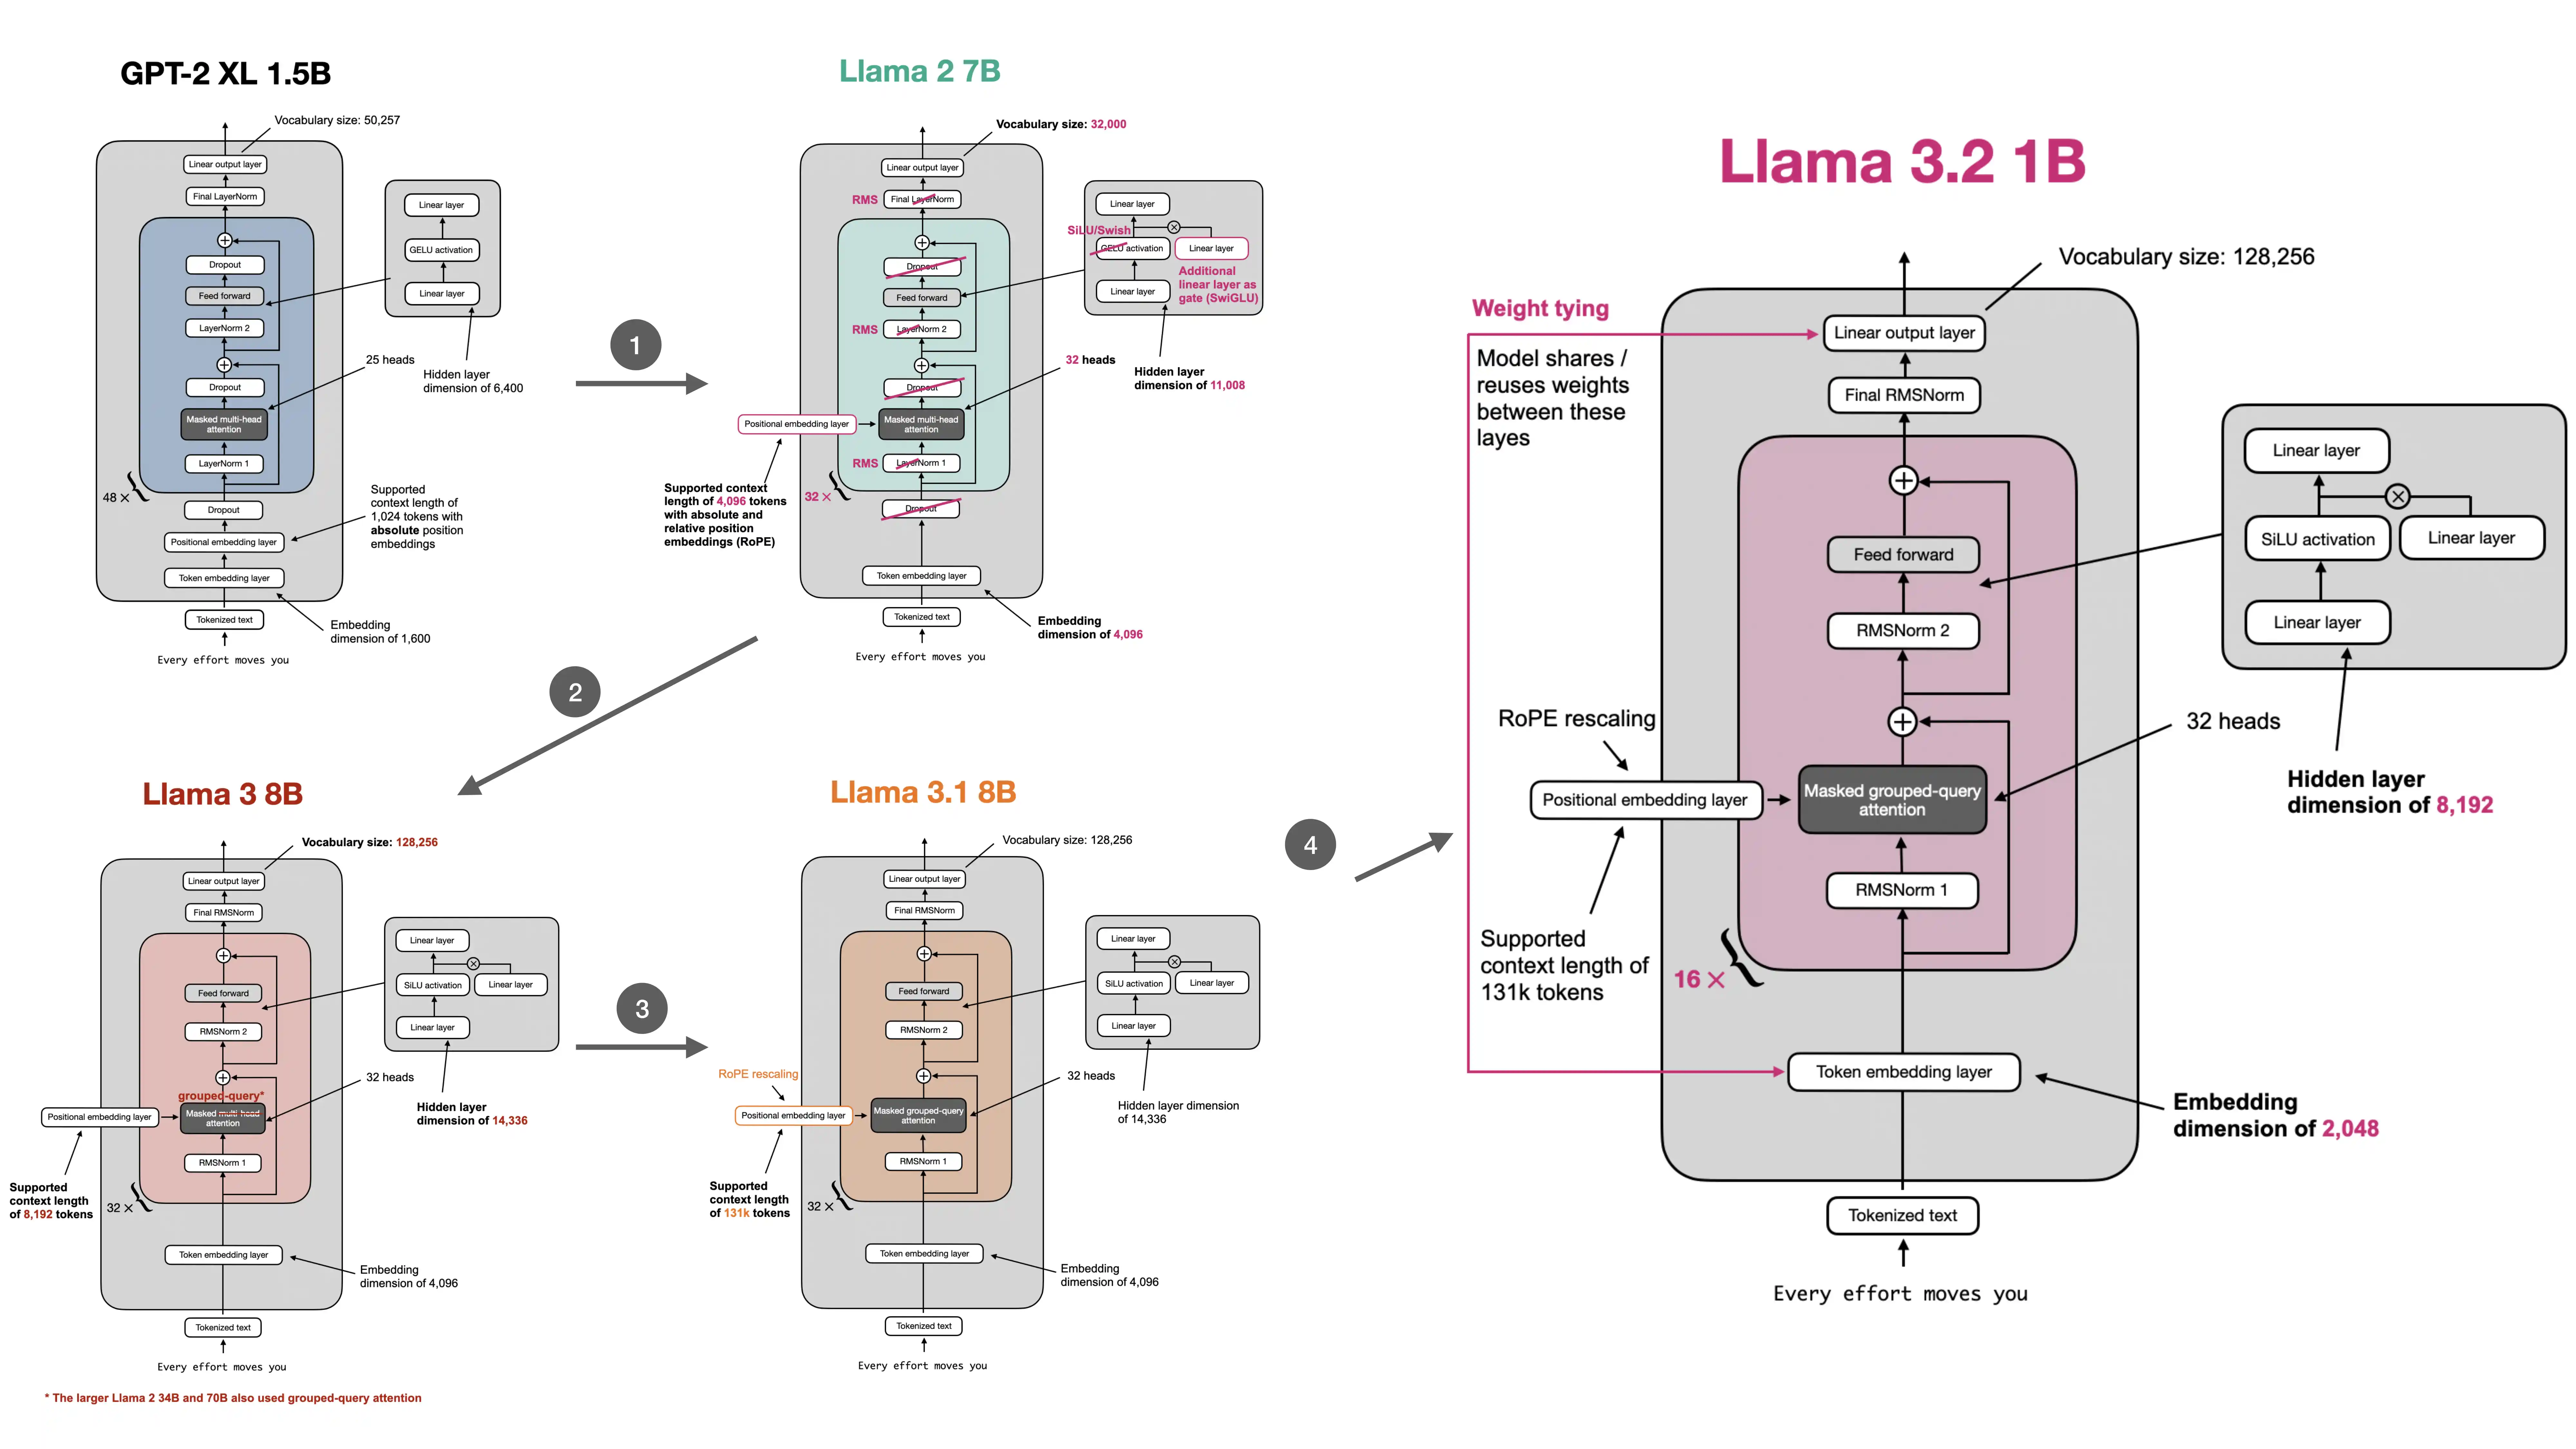